In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

from datetime import date
date.today()

Python 3.10.13


datetime.date(2025, 8, 19)

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat
import xesmf as xe

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path
from typing import Union, Optional, Dict, List, Tuple, Sequence

import importlib

from TEXAS.stan.sampler import get_posterior, load_posterior
from TEXAS.ensemble.generator import generate_ensemble, generate_ensemble_auto
from TEXAS.plotting import prior_plot as ppd
from TEXAS.stan.invT import build_invT_inputData
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.io import load_posterior
from TEXAS.data.builder import build_invT_inputData, InvTConfig

import TEXAS
print("TEXAS version",TEXAS.__version__)  


import bayspline as bsl
import bayspar as bsr



TEXAS version 0.1.0


# Miscellaneous functions

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

# Concordance correlation coefficient (CCC)
def concordance_corr_coef(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)

def running_mean(x, y, window_size):
    df = pd.DataFrame({'x': x, 'y': y})
    df = df.sort_values(by='x')
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    return df['x'], df['y_running_mean']


def running_mean_log10(x, y, window_size, weights=None):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    if weights is not None:
        df['y_running_mean'] = df['y_running_mean'] * weights
    
    return df['log_x'], df['y_running_mean']

def running_median_log10(x, y, window_size):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_median'] = df['y'].rolling(window=window_size, center=True).median()
    
    return df['log_x'], df['y_running_median']
    
    
def flag_quantile_outliers(df, x_col, y_col, 
                           nbins=30, lower_q=0.10, upper_q=0.90):
    df = df.copy()
    df['bin'] = pd.qcut(np.log10(df[x_col]), q=nbins, duplicates='drop')
    df['outlier'] = False

    for b in df['bin'].unique():
        bin_mask = df['bin'] == b
        residuals_in_bin = df.loc[bin_mask, y_col]
        q_low = np.nanquantile(residuals_in_bin, lower_q)
        q_high = np.nanquantile(residuals_in_bin, upper_q)

        outlier_mask = (residuals_in_bin < q_low) | (residuals_in_bin > q_high)
        df.loc[bin_mask, 'outlier'] = outlier_mask

    return df


def bland_altman_metrics_calculation(data1, data2):
    """"

    # Example to use the metrics
    # fig, axs = plot.subplots()
    # axs.scatter(mean, diff, *args, **kwargs)  # Plot differences against means
    # axs.axhline(md, color='gray', linestyle='--', label='Mean Difference')
    # axs.axhline(md + 1.96 * sd, color='orange', linestyle='--', label='+1.96 SD (Upper LoA)')
    # axs.axhline(md - 1.96 * sd, color='magenta', linestyle='--', label='-1.96 SD (Lower LoA)')
    """
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    
    mean = np.mean([data1, data2], axis=0)  # Calculate the average of the two measurements
    diff = data1 - data2  # Calculate the difference between the two measurements
    
    md = np.mean(diff)  # Mean of the differences (estimated bias)
    sd = np.std(diff, axis=0)  # Standard deviation of the differences
    

    
    return mean, diff, md, sd



# Miscellaneous functions

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

# Concordance correlation coefficient (CCC)
def concordance_corr_coef(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)

def running_mean(x, y, window_size):
    df = pd.DataFrame({'x': x, 'y': y})
    df = df.sort_values(by='x')
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    return df['x'], df['y_running_mean']


def running_mean_log10(x, y, window_size, weights=None):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    if weights is not None:
        df['y_running_mean'] = df['y_running_mean'] * weights
    
    return df['log_x'], df['y_running_mean']

def running_median_log10(x, y, window_size):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_median'] = df['y'].rolling(window=window_size, center=True).median()
    
    return df['log_x'], df['y_running_median']
    
    
def flag_quantile_outliers(df, x_col, y_col, 
                           nbins=30, lower_q=0.10, upper_q=0.90):
    df = df.copy()
    df['bin'] = pd.qcut(np.log10(df[x_col]), q=nbins, duplicates='drop')
    df['outlier'] = False

    for b in df['bin'].unique():
        bin_mask = df['bin'] == b
        residuals_in_bin = df.loc[bin_mask, y_col]
        q_low = np.nanquantile(residuals_in_bin, lower_q)
        q_high = np.nanquantile(residuals_in_bin, upper_q)

        outlier_mask = (residuals_in_bin < q_low) | (residuals_in_bin > q_high)
        df.loc[bin_mask, 'outlier'] = outlier_mask

    return df


def bland_altman_metrics_calculation(data1, data2):
    """"

    # Example to use the metrics
    # fig, axs = plot.subplots()
    # axs.scatter(mean, diff, *args, **kwargs)  # Plot differences against means
    # axs.axhline(md, color='gray', linestyle='--', label='Mean Difference')
    # axs.axhline(md + 1.96 * sd, color='orange', linestyle='--', label='+1.96 SD (Upper LoA)')
    # axs.axhline(md - 1.96 * sd, color='magenta', linestyle='--', label='-1.96 SD (Lower LoA)')
    """
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    
    mean = np.mean([data1, data2], axis=0)  # Calculate the average of the two measurements
    diff = data1 - data2  # Calculate the difference between the two measurements
    
    md = np.mean(diff)  # Mean of the differences (estimated bias)
    sd = np.std(diff, axis=0)  # Standard deviation of the differences
    

    
    return mean, diff, md, sd



# Previous TEX86 calibration models

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [6]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [7]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [8]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/TEXAS /home/micromamba/app/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
def pred_texRI(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Miscellaneous functions

In [11]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

# Concordance correlation coefficient (CCC)
def concordance_corr_coef(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)

def running_mean(x, y, window_size):
    df = pd.DataFrame({'x': x, 'y': y})
    df = df.sort_values(by='x')
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    return df['x'], df['y_running_mean']


def running_mean_log10(x, y, window_size, weights=None):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    if weights is not None:
        df['y_running_mean'] = df['y_running_mean'] * weights
    
    return df['log_x'], df['y_running_mean']

def running_median_log10(x, y, window_size):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_median'] = df['y'].rolling(window=window_size, center=True).median()
    
    return df['log_x'], df['y_running_median']
    
    
def flag_quantile_outliers(df, x_col, y_col, 
                           nbins=30, lower_q=0.10, upper_q=0.90):
    df = df.copy()
    df['bin'] = pd.qcut(np.log10(df[x_col]), q=nbins, duplicates='drop')
    df['outlier'] = False

    for b in df['bin'].unique():
        bin_mask = df['bin'] == b
        residuals_in_bin = df.loc[bin_mask, y_col]
        q_low = np.nanquantile(residuals_in_bin, lower_q)
        q_high = np.nanquantile(residuals_in_bin, upper_q)

        outlier_mask = (residuals_in_bin < q_low) | (residuals_in_bin > q_high)
        df.loc[bin_mask, 'outlier'] = outlier_mask

    return df


def bland_altman_metrics_calculation(data1, data2):
    """"

    # Example to use the metrics
    # fig, axs = plot.subplots()
    # axs.scatter(mean, diff, *args, **kwargs)  # Plot differences against means
    # axs.axhline(md, color='gray', linestyle='--', label='Mean Difference')
    # axs.axhline(md + 1.96 * sd, color='orange', linestyle='--', label='+1.96 SD (Upper LoA)')
    # axs.axhline(md - 1.96 * sd, color='magenta', linestyle='--', label='-1.96 SD (Lower LoA)')
    """
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    
    mean = np.mean([data1, data2], axis=0)  # Calculate the average of the two measurements
    diff = data1 - data2  # Calculate the difference between the two measurements
    
    md = np.mean(diff)  # Mean of the differences (estimated bias)
    sd = np.std(diff, axis=0)  # Standard deviation of the differences
    

    
    return mean, diff, md, sd



# Previous TEX86 calibration models

In [12]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [13]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [14]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [15]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/TEXAS /home/micromamba/app/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [16]:
def pred_texRI(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Raw coretop

In [17]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['pred_new_texRI'] = pred_texRI(raw_coretop_df['TEX86'], method_name='exp_thisStudy')
raw_coretop_df['new_deltaRI'] = raw_coretop_df['scaledRI'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,deltaRI_group,pred_new_texRI,new_deltaRI
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.0,6.0,31.651700,34.07330,562.0,0.662000,...,0.003865,0.025728,NaN,NaN,NaN,NaN,NaN,NaN,2.649848,NaN
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.532700,-86.78520,2288.0,0.602873,...,8.300386,5.318187,10.0,East Equatorial Pacific,1.886982,0.894152,False,-0.3 to 0.3,2.434261,-1.848859
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.0,1.0,-3.710500,-81.11530,378.0,0.570000,...,5.804398,4.208444,NaN,NaN,NaN,NaN,NaN,NaN,2.322082,NaN
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.0,1.0,-3.750200,-81.13580,379.0,0.572000,...,7.112034,5.378340,NaN,NaN,NaN,NaN,NaN,NaN,2.328756,NaN
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.969000,-81.31000,1024.0,0.599447,...,6.462469,4.969550,10.0,East Equatorial Pacific,1.217141,0.946764,False,-0.3 to 0.3,2.422321,-1.780690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.600000,-65.40000,267.0,0.400000,...,3.155563,3.107517,60.0,Baffin Bay,4.267857,0.707148,False,>0.3,1.819351,-1.520851
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.410000,-64.40000,1054.0,0.322581,...,3.043328,2.995078,60.0,Baffin Bay,3.700127,0.751740,False,>0.3,1.628025,-1.355025
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.970000,-59.49000,1012.0,0.375000,...,2.829360,2.795761,60.0,Baffin Bay,4.128651,0.718082,False,>0.3,1.755230,-1.450230
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0,3.0,-31.584330,164.44867,2131.0,0.671171,...,0.917937,0.575588,61.0,Tasman Sea,1.925943,0.891092,False,-0.3 to 0.3,2.684958,-2.062401


# Gridded coretop

In [18]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds_gridded_coretop_tex_scaledRI_revised_081525.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [19]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)  
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,3960.0,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,-1.48951,1.750199,0.036001
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041,1.654927,0.181673
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180,1.921330,-0.321930
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371,2.100132,-0.367832


# Calculations for Predicted TEX/RI vs Observed TEX/RI

In [20]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'combined_df_culmesocore_griddedRI.csv'
combined_df = pd.read_csv(os.path.join(fpath,fname))
combined_df

,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype
0,0,-1.636017,-1.64841,0.509982,0.413650,1.502839,NaN,coretop
1,1,-1.586854,-1.50741,0.438075,0.351000,2.833333,NaN,coretop
2,2,-1.692642,-1.70171,0.410931,0.367016,1.824832,NaN,coretop
3,3,-1.498910,-1.42831,0.433342,0.335974,2.066396,28.365620,coretop
4,4,-1.651191,-1.74881,0.447518,0.342342,2.040640,29.118933,coretop
...,...,...,...,...,...,...,...,...
1381,16,25.000000,25.00000,0.693123,0.449778,2.629108,50.000000,mesocosm
1382,17,32.000000,32.00000,0.656972,0.683519,3.553719,50.000000,mesocosm
1383,18,34.000000,34.00000,0.809038,0.606766,2.318038,50.000000,mesocosm
1384,19,36.000000,36.00000,0.899697,0.813041,2.396907,50.000000,mesocosm


In [41]:
plot_data = combined_df[combined_df['datatype']!='coretop']

TEX_models = ['schouten2002','kim2010_tex86H']
for method in TEX_models:
    plot_data[f'predTEX_{method}'] = predictTEXfromSST(plot_data['SST'],method_name=method)
    plot_data[f'predSST_{method}'] = predictSSTfromTEX(plot_data['TEX86'],method_name=method)
    
    plot_data[f'TEXres_{method}'] = plot_data['TEX86'] - plot_data[f'predTEX_{method}']
    plot_data[f'SSTres_{method}'] = plot_data['SST'] - plot_data[f'predSST_{method}']
    
plot_data['predRI_sim_logi_Tonly'] = generate_ensemble_auto(
    load_posterior('hier_crtp_univ_priorApprox_sst'),
    x_vals = plot_data['SST'])['p50']
plot_data['RIres_sim_logi_Tonly'] = plot_data['scaledRI'] - plot_data['predRI_sim_logi_Tonly']

plot_data['predRI_sim_logi_T-g23r'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_sst_gdgt23ratio'),
    x_vals = plot_data['SST'],
    gdgt23ratio = plot_data['gdgt23ratio'],)['p50']
plot_data['RIres_sim_logi_T-g23r'] = plot_data['scaledRI'] - plot_data['predRI_sim_logi_T-g23r']

plot_data['predRI_sim_logi_Tonly_new'] = generate_ensemble_auto(
    load_posterior('hier_crtp_univ_sst_test01_cln_crtp'),
    x_vals = plot_data['SST'])['p50']
plot_data['RIres_Tonly_new'] = plot_data['scaledRI'] - plot_data['predRI_sim_logi_Tonly_new']

plot_data['predRI_sim_logi_T-g23r_new'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp'),
    x_vals = plot_data['SST'],
    gdgt23ratio = plot_data['gdgt23ratio'],)['p50']
plot_data['RIres_sim_logi_T-g23r_new'] = plot_data['scaledRI'] - plot_data['predRI_sim_logi_T-g23r_new']

########################
    
plot_data['predRI_Tonly'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_sst'),
    x_vals = plot_data['SST'])['p50']
plot_data['RIres_Tonly'] = plot_data['scaledRI'] - plot_data['predRI_Tonly']

plot_data['predRI_T-g23r'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio'),
    x_vals = plot_data['SST'],
    gdgt23ratio = plot_data['gdgt23ratio'],)['p50']
plot_data['RIres_T-g23r'] = plot_data['scaledRI'] - plot_data['predRI_T-g23r']

plot_data['predRI_Tonly_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp'),
    x_vals = plot_data['SST'])['p50']
plot_data['RIres_Tonly_new'] = plot_data['scaledRI'] - plot_data['predRI_Tonly_new']

plot_data['predRI_T-g23r_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp'),
    x_vals = plot_data['SST'],
    gdgt23ratio = plot_data['gdgt23ratio'],)['p50']
plot_data['RIres_T-g23r_new'] = plot_data['scaledRI'] - plot_data['predRI_T-g23r_new']



In [22]:
# 1. Create a boolean mask for rows where BOTH columns are valid
nonnan_idx = pd.notna(plot_data['scaledRI']) & pd.notna(plot_data['SST'])

# You can see how many valid rows you have:
print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# 2. Use the mask to select clean data for the model
# .loc[nonnan_idx] selects only the rows where the index is True
results_dict = TEXAS.stan.predict_temperature_from_RI(
    scaledRI=plot_data.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
    prior_mu_t=plot_data.loc[nonnan_idx, 'SST'].values,
    prior_sigma_t=6,
    fwd_posterior_name='hier_crtp_univ_priorApprox_sst',
    site_name='cul-meso',
    temptype='sst',
    iter_warmup=200,
    iter_sampling=500,
    save_results=True
)

# 3. Assign the results back to the original dataframe in the correct spots
# This works because the boolean index aligns the results perfectly.
plot_data.loc[nonnan_idx, 'predSST_simple_logi_Tonly'] = results_dict['p50']

plot_data

19:55:56 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
🔍 Automatically selected Stan file: invT_logistic_fixed_univ
| M=100 N=100
🔧 Compiling Stan model: invT_logistic_fixed_univ.stan
✅ Compiled: invT_logistic_fixed_univ.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

19:57:15 - cmdstanpy - INFO - CmdStan done processing.



✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_logistic_fixed_univ_sst.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_logistic_fixed_univ_sst.npz


,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,predTEX_schouten02,predSST_schouten02,...,predRI_sim_logi_T-g23r_new,RIres_sim_logi_T-g23r_new,predRI_Tonly,RIres_Tonly,predRI_T-g23r,RIres_T-g23r,predRI_Tonly_new,predRI_T-g23r_new,RIres_T-g23r_new,predSST_simple_logi_Tonly
1286,0,37.0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.947563,22.343812,...,0.851769,-0.153631,0.854341,-0.156203,0.870534,-0.172396,0.858096,0.874839,-0.176701,30.80330
1287,1,46.0,46.0,0.933659,0.806931,0.482759,50.0,culture,1.282883,32.227598,...,0.935226,-0.001567,0.961225,-0.027565,0.961162,-0.027502,0.961991,0.963419,-0.029760,47.14465
1288,2,18.0,18.0,0.609394,0.858108,0.402266,50.0,culture,0.499839,34.054273,...,0.579634,0.029760,0.546026,0.063368,0.579974,0.029420,0.547570,0.579985,0.029408,20.94205
1289,3,22.0,22.0,0.558857,0.827338,1.088785,50.0,culture,0.571887,32.969520,...,0.626323,-0.067466,0.591662,-0.032805,0.623839,-0.064981,0.594109,0.624457,-0.065600,19.75160
1290,4,28.0,28.0,0.629379,0.868762,1.064516,50.0,culture,0.699889,34.420801,...,0.717220,-0.087842,0.684972,-0.055594,0.715395,-0.086016,0.688880,0.718251,-0.088872,25.21110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,16,25.0,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.632659,14.865049,...,0.661434,0.031689,0.634643,0.058480,0.657965,0.035158,0.637675,0.659646,0.033476,27.52710
1382,17,32.0,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.800772,27.296945,...,0.765473,-0.108501,0.760486,-0.103514,0.770861,-0.113889,0.764868,0.775158,-0.118187,27.58470
1383,18,34.0,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.856542,23.758670,...,0.801658,0.007380,0.799074,0.009964,0.812555,-0.003516,0.803739,0.816962,-0.007924,35.48780
1384,19,36.0,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.916196,32.451709,...,0.828305,0.071392,0.836733,0.062964,0.844340,0.055357,0.840649,0.849173,0.050524,40.64370


In [23]:
# 1. Create a boolean mask for rows where BOTH columns are valid
nonnan_idx = pd.notna(plot_data['scaledRI']) & pd.notna(plot_data['SST'])

# You can see how many valid rows you have:
print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# 2. Use the mask to select clean data for the model
# .loc[nonnan_idx] selects only the rows where the index is True
results_dict = TEXAS.stan.predict_temperature_from_RI(
    scaledRI=plot_data.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
    prior_mu_t=plot_data.loc[nonnan_idx, 'SST'].values,
    prior_sigma_t=6,
    fwd_posterior_name='hier_crtp_multiv_sst_gdgt23ratio',
    site_name='cul-meso',
    temptype='sst',
    iter_warmup=200,
    iter_sampling=500,
    save_results=True,
    predictors={
        'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio'].values
    }
)

# 3. Assign the results back to the original dataframe in the correct spots
# This works because the boolean index aligns the results perfectly.
plot_data.loc[nonnan_idx, 'predSST_Tonly'] = results_dict['p50']

plot_data


19:57:19 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
🔍 Automatically selected Stan file: invT_logistic_fixed_multiv
| M=100 N=100
🔧 Compiling Stan model: invT_logistic_fixed_multiv.stan
✅ Compiled: invT_logistic_fixed_multiv.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

19:57:45 - cmdstanpy - INFO - CmdStan done processing.



✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_logistic_fixed_multiv_sst_gdgt23ratio.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_logistic_fixed_multiv_sst_gdgt23ratio.npz


,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,predTEX_schouten02,predSST_schouten02,...,RIres_sim_logi_T-g23r_new,predRI_Tonly,RIres_Tonly,predRI_T-g23r,RIres_T-g23r,predRI_Tonly_new,predRI_T-g23r_new,RIres_T-g23r_new,predSST_simple_logi_Tonly,predSST_Tonly
1286,0,37.0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.947563,22.343812,...,-0.153631,0.854341,-0.156203,0.870534,-0.172396,0.858096,0.874839,-0.176701,30.80330,29.26620
1287,1,46.0,46.0,0.933659,0.806931,0.482759,50.0,culture,1.282883,32.227598,...,-0.001567,0.961225,-0.027565,0.961162,-0.027502,0.961991,0.963419,-0.029760,47.14465,46.80110
1288,2,18.0,18.0,0.609394,0.858108,0.402266,50.0,culture,0.499839,34.054273,...,0.029760,0.546026,0.063368,0.579974,0.029420,0.547570,0.579985,0.029408,20.94205,19.20580
1289,3,22.0,22.0,0.558857,0.827338,1.088785,50.0,culture,0.571887,32.969520,...,-0.067466,0.591662,-0.032805,0.623839,-0.064981,0.594109,0.624457,-0.065600,19.75160,18.09845
1290,4,28.0,28.0,0.629379,0.868762,1.064516,50.0,culture,0.699889,34.420801,...,-0.087842,0.684972,-0.055594,0.715395,-0.086016,0.688880,0.718251,-0.088872,25.21110,23.64840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,16,25.0,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.632659,14.865049,...,0.031689,0.634643,0.058480,0.657965,0.035158,0.637675,0.659646,0.033476,27.52710,26.58500
1382,17,32.0,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.800772,27.296945,...,-0.108501,0.760486,-0.103514,0.770861,-0.113889,0.764868,0.775158,-0.118187,27.58470,26.80320
1383,18,34.0,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.856542,23.758670,...,0.007380,0.799074,0.009964,0.812555,-0.003516,0.803739,0.816962,-0.007924,35.48780,34.90830
1384,19,36.0,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.916196,32.451709,...,0.071392,0.836733,0.062964,0.844340,0.055357,0.840649,0.849173,0.050524,40.64370,40.50470


In [24]:
# 1. Create a boolean mask for rows where BOTH columns are valid
nonnan_idx = pd.notna(plot_data['scaledRI']) & pd.notna(plot_data['SST'])

# You can see how many valid rows you have:
print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# 2. Use the mask to select clean data for the model
# .loc[nonnan_idx] selects only the rows where the index is True
results_dict = TEXAS.stan.predict_temperature_from_RI(
    scaledRI=plot_data.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
    prior_mu_t=plot_data.loc[nonnan_idx, 'SST'].values,
    prior_sigma_t=6,
    fwd_posterior_name='hier_crtp_multiv_sst_gdgt23ratio_no3_1.5',
    site_name='cul-meso',
    temptype='sst',
    iter_warmup=200,
    iter_sampling=500,
    save_results=True,
    predictors={
        'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio'].values,
        'no3': np.full(len(plot_data),50)
    }
)

# 3. Assign the results back to the original dataframe in the correct spots
# This works because the boolean index aligns the results perfectly.
plot_data.loc[nonnan_idx, 'predSST_Tonly'] = results_dict['p50']

plot_data

19:57:49 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
💡 Using no3_cutoff from forward posterior attributes: 1.5
🔍 Automatically selected Stan file: invT_logistic_fixed_multiv
| M=100 N=100


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

19:58:31 - cmdstanpy - INFO - CmdStan done processing.



✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_logistic_fixed_multiv_sst_gdgt23ratio_no3_1.5.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_logistic_fixed_multiv_sst_gdgt23ratio_no3_1.5.npz


,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,predTEX_schouten02,predSST_schouten02,...,RIres_sim_logi_T-g23r_new,predRI_Tonly,RIres_Tonly,predRI_T-g23r,RIres_T-g23r,predRI_Tonly_new,predRI_T-g23r_new,RIres_T-g23r_new,predSST_simple_logi_Tonly,predSST_Tonly
1286,0,37.0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.947563,22.343812,...,-0.153631,0.854341,-0.156203,0.870534,-0.172396,0.858096,0.874839,-0.176701,30.80330,30.19185
1287,1,46.0,46.0,0.933659,0.806931,0.482759,50.0,culture,1.282883,32.227598,...,-0.001567,0.961225,-0.027565,0.961162,-0.027502,0.961991,0.963419,-0.029760,47.14465,47.59215
1288,2,18.0,18.0,0.609394,0.858108,0.402266,50.0,culture,0.499839,34.054273,...,0.029760,0.546026,0.063368,0.579974,0.029420,0.547570,0.579985,0.029408,20.94205,20.00430
1289,3,22.0,22.0,0.558857,0.827338,1.088785,50.0,culture,0.571887,32.969520,...,-0.067466,0.591662,-0.032805,0.623839,-0.064981,0.594109,0.624457,-0.065600,19.75160,18.69705
1290,4,28.0,28.0,0.629379,0.868762,1.064516,50.0,culture,0.699889,34.420801,...,-0.087842,0.684972,-0.055594,0.715395,-0.086016,0.688880,0.718251,-0.088872,25.21110,24.47515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,16,25.0,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.632659,14.865049,...,0.031689,0.634643,0.058480,0.657965,0.035158,0.637675,0.659646,0.033476,27.52710,27.64560
1382,17,32.0,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.800772,27.296945,...,-0.108501,0.760486,-0.103514,0.770861,-0.113889,0.764868,0.775158,-0.118187,27.58470,27.70040
1383,18,34.0,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.856542,23.758670,...,0.007380,0.799074,0.009964,0.812555,-0.003516,0.803739,0.816962,-0.007924,35.48780,36.05690
1384,19,36.0,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.916196,32.451709,...,0.071392,0.836733,0.062964,0.844340,0.055357,0.840649,0.849173,0.050524,40.64370,41.74075


In [25]:
# 1. Create a boolean mask for rows where BOTH columns are valid
nonnan_idx = pd.notna(plot_data['scaledRI']) & pd.notna(plot_data['SST'])

# You can see how many valid rows you have:
print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# 2. Use the mask to select clean data for the model
# .loc[nonnan_idx] selects only the rows where the index is True
results_dict = TEXAS.stan.predict_temperature_from_RI(
    scaledRI=plot_data.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
    prior_mu_t=plot_data.loc[nonnan_idx, 'SST'].values,
    prior_sigma_t=6,
    fwd_posterior_name='gen_logi_fixed_hier_crtp_univ_priorApprox_sst',
    site_name='cul-meso',
    temptype='sst',
    iter_warmup=200,
    iter_sampling=500,
    save_results=True
)

# 3. Assign the results back to the original dataframe in the correct spots
# This works because the boolean index aligns the results perfectly.
plot_data.loc[nonnan_idx, 'predSST_Tonly'] = results_dict['p50']

plot_data


19:58:35 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
🔍 Automatically selected Stan file: invT_gen_logi_fixed_univ
| M=100 N=100
🔧 Compiling Stan model: invT_gen_logi_fixed_univ.stan
✅ Compiled: invT_gen_logi_fixed_univ.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:01:04 - cmdstanpy - INFO - CmdStan done processing.



✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_gen_logi_fixed_univ_sst.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_gen_logi_fixed_univ_sst.npz


,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,predTEX_schouten02,predSST_schouten02,...,RIres_sim_logi_T-g23r_new,predRI_Tonly,RIres_Tonly,predRI_T-g23r,RIres_T-g23r,predRI_Tonly_new,predRI_T-g23r_new,RIres_T-g23r_new,predSST_simple_logi_Tonly,predSST_Tonly
1286,0,37.0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.947563,22.343812,...,-0.153631,0.854341,-0.156203,0.870534,-0.172396,0.858096,0.874839,-0.176701,30.80330,30.22475
1287,1,46.0,46.0,0.933659,0.806931,0.482759,50.0,culture,1.282883,32.227598,...,-0.001567,0.961225,-0.027565,0.961162,-0.027502,0.961991,0.963419,-0.029760,47.14465,45.71695
1288,2,18.0,18.0,0.609394,0.858108,0.402266,50.0,culture,0.499839,34.054273,...,0.029760,0.546026,0.063368,0.579974,0.029420,0.547570,0.579985,0.029408,20.94205,20.89060
1289,3,22.0,22.0,0.558857,0.827338,1.088785,50.0,culture,0.571887,32.969520,...,-0.067466,0.591662,-0.032805,0.623839,-0.064981,0.594109,0.624457,-0.065600,19.75160,19.77965
1290,4,28.0,28.0,0.629379,0.868762,1.064516,50.0,culture,0.699889,34.420801,...,-0.087842,0.684972,-0.055594,0.715395,-0.086016,0.688880,0.718251,-0.088872,25.21110,25.16490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,16,25.0,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.632659,14.865049,...,0.031689,0.634643,0.058480,0.657965,0.035158,0.637675,0.659646,0.033476,27.52710,27.41670
1382,17,32.0,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.800772,27.296945,...,-0.108501,0.760486,-0.103514,0.770861,-0.113889,0.764868,0.775158,-0.118187,27.58470,27.38710
1383,18,34.0,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.856542,23.758670,...,0.007380,0.799074,0.009964,0.812555,-0.003516,0.803739,0.816962,-0.007924,35.48780,34.53645
1384,19,36.0,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.916196,32.451709,...,0.071392,0.836733,0.062964,0.844340,0.055357,0.840649,0.849173,0.050524,40.64370,39.32095


In [26]:
# 1. Create a boolean mask for rows where BOTH columns are valid
nonnan_idx = pd.notna(plot_data['scaledRI']) & pd.notna(plot_data['SST'])

# You can see how many valid rows you have:
print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# 2. Use the mask to select clean data for the model
# .loc[nonnan_idx] selects only the rows where the index is True
results_dict = TEXAS.stan.predict_temperature_from_RI(
    scaledRI=plot_data.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
    prior_mu_t=plot_data.loc[nonnan_idx, 'SST'].values,
    prior_sigma_t=6,
    fwd_posterior_name='gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio',
    site_name='cul-meso',
    temptype='sst',
    iter_warmup=200,
    iter_sampling=500,
    save_results=True,
    predictors={
        'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio'].values
    }
)

# 3. Assign the results back to the original dataframe in the correct spots
# This works because the boolean index aligns the results perfectly.
plot_data.loc[nonnan_idx, 'predSST_Tonly'] = results_dict['p50']

plot_data


20:01:08 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
🔍 Automatically selected Stan file: invT_gen_logi_fixed_multiv
| M=100 N=100
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv.stan
✅ Compiled: invT_gen_logi_fixed_multiv.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:02:22 - cmdstanpy - INFO - CmdStan done processing.



✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_gen_logi_fixed_multiv_sst_gdgt23ratio.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_gen_logi_fixed_multiv_sst_gdgt23ratio.npz


,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,predTEX_schouten02,predSST_schouten02,...,RIres_sim_logi_T-g23r_new,predRI_Tonly,RIres_Tonly,predRI_T-g23r,RIres_T-g23r,predRI_Tonly_new,predRI_T-g23r_new,RIres_T-g23r_new,predSST_simple_logi_Tonly,predSST_Tonly
1286,0,37.0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.947563,22.343812,...,-0.153631,0.854341,-0.156203,0.870534,-0.172396,0.858096,0.874839,-0.176701,30.80330,28.81825
1287,1,46.0,46.0,0.933659,0.806931,0.482759,50.0,culture,1.282883,32.227598,...,-0.001567,0.961225,-0.027565,0.961162,-0.027502,0.961991,0.963419,-0.029760,47.14465,45.50600
1288,2,18.0,18.0,0.609394,0.858108,0.402266,50.0,culture,0.499839,34.054273,...,0.029760,0.546026,0.063368,0.579974,0.029420,0.547570,0.579985,0.029408,20.94205,19.15610
1289,3,22.0,22.0,0.558857,0.827338,1.088785,50.0,culture,0.571887,32.969520,...,-0.067466,0.591662,-0.032805,0.623839,-0.064981,0.594109,0.624457,-0.065600,19.75160,18.11070
1290,4,28.0,28.0,0.629379,0.868762,1.064516,50.0,culture,0.699889,34.420801,...,-0.087842,0.684972,-0.055594,0.715395,-0.086016,0.688880,0.718251,-0.088872,25.21110,23.62315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,16,25.0,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.632659,14.865049,...,0.031689,0.634643,0.058480,0.657965,0.035158,0.637675,0.659646,0.033476,27.52710,26.52735
1382,17,32.0,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.800772,27.296945,...,-0.108501,0.760486,-0.103514,0.770861,-0.113889,0.764868,0.775158,-0.118187,27.58470,26.62410
1383,18,34.0,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.856542,23.758670,...,0.007380,0.799074,0.009964,0.812555,-0.003516,0.803739,0.816962,-0.007924,35.48780,34.06290
1384,19,36.0,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.916196,32.451709,...,0.071392,0.836733,0.062964,0.844340,0.055357,0.840649,0.849173,0.050524,40.64370,39.33370


In [27]:
# 1. Create a boolean mask for rows where BOTH columns are valid
nonnan_idx = pd.notna(plot_data['scaledRI']) & pd.notna(plot_data['SST'])

# You can see how many valid rows you have:
print(f"Found {nonnan_idx.sum()} valid rows out of {len(plot_data)}")

# 2. Use the mask to select clean data for the model
# .loc[nonnan_idx] selects only the rows where the index is True
results_dict = TEXAS.stan.predict_temperature_from_RI(
    scaledRI=plot_data.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
    prior_mu_t=plot_data.loc[nonnan_idx, 'SST'].values,
    prior_sigma_t=6,
    fwd_posterior_name='gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5',
    site_name='cul-meso',
    temptype='sst',
    iter_warmup=200,
    iter_sampling=500,
    save_results=True,
    predictors={
        'gdgt23ratio': plot_data.loc[nonnan_idx, 'gdgt23ratio'].values,
        'no3': np.full(len(plot_data),50)
    }
)

# 3. Assign the results back to the original dataframe in the correct spots
# This works because the boolean index aligns the results perfectly.
plot_data.loc[nonnan_idx, 'predSST_Tonly'] = results_dict['p50']

plot_data

20:02:26 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
💡 Using no3_cutoff from forward posterior attributes: 1.5
🔍 Automatically selected Stan file: invT_gen_logi_fixed_multiv
| M=100 N=100


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:04:03 - cmdstanpy - INFO - CmdStan done processing.



✅ Posterior saved to /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_gen_logi_fixed_multiv_sst_gdgt23ratio_no3_1.5.nc
✅ invT results saved: /home/micromamba/app/TEXAS/invT_posterior_cache/cul-meso_invT_gen_logi_fixed_multiv_sst_gdgt23ratio_no3_1.5.npz


,Unnamed: 0,t_sf2tc,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,predTEX_schouten02,predSST_schouten02,...,RIres_sim_logi_T-g23r_new,predRI_Tonly,RIres_Tonly,predRI_T-g23r,RIres_T-g23r,predRI_Tonly_new,predRI_T-g23r_new,RIres_T-g23r_new,predSST_simple_logi_Tonly,predSST_Tonly
1286,0,37.0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.947563,22.343812,...,-0.153631,0.854341,-0.156203,0.870534,-0.172396,0.858096,0.874839,-0.176701,30.80330,29.63535
1287,1,46.0,46.0,0.933659,0.806931,0.482759,50.0,culture,1.282883,32.227598,...,-0.001567,0.961225,-0.027565,0.961162,-0.027502,0.961991,0.963419,-0.029760,47.14465,45.80170
1288,2,18.0,18.0,0.609394,0.858108,0.402266,50.0,culture,0.499839,34.054273,...,0.029760,0.546026,0.063368,0.579974,0.029420,0.547570,0.579985,0.029408,20.94205,19.96630
1289,3,22.0,22.0,0.558857,0.827338,1.088785,50.0,culture,0.571887,32.969520,...,-0.067466,0.591662,-0.032805,0.623839,-0.064981,0.594109,0.624457,-0.065600,19.75160,18.73945
1290,4,28.0,28.0,0.629379,0.868762,1.064516,50.0,culture,0.699889,34.420801,...,-0.087842,0.684972,-0.055594,0.715395,-0.086016,0.688880,0.718251,-0.088872,25.21110,24.45525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,16,25.0,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.632659,14.865049,...,0.031689,0.634643,0.058480,0.657965,0.035158,0.637675,0.659646,0.033476,27.52710,27.54370
1382,17,32.0,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.800772,27.296945,...,-0.108501,0.760486,-0.103514,0.770861,-0.113889,0.764868,0.775158,-0.118187,27.58470,27.44905
1383,18,34.0,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.856542,23.758670,...,0.007380,0.799074,0.009964,0.812555,-0.003516,0.803739,0.816962,-0.007924,35.48780,34.96160
1384,19,36.0,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.916196,32.451709,...,0.071392,0.836733,0.062964,0.844340,0.055357,0.840649,0.849173,0.050524,40.64370,40.16735


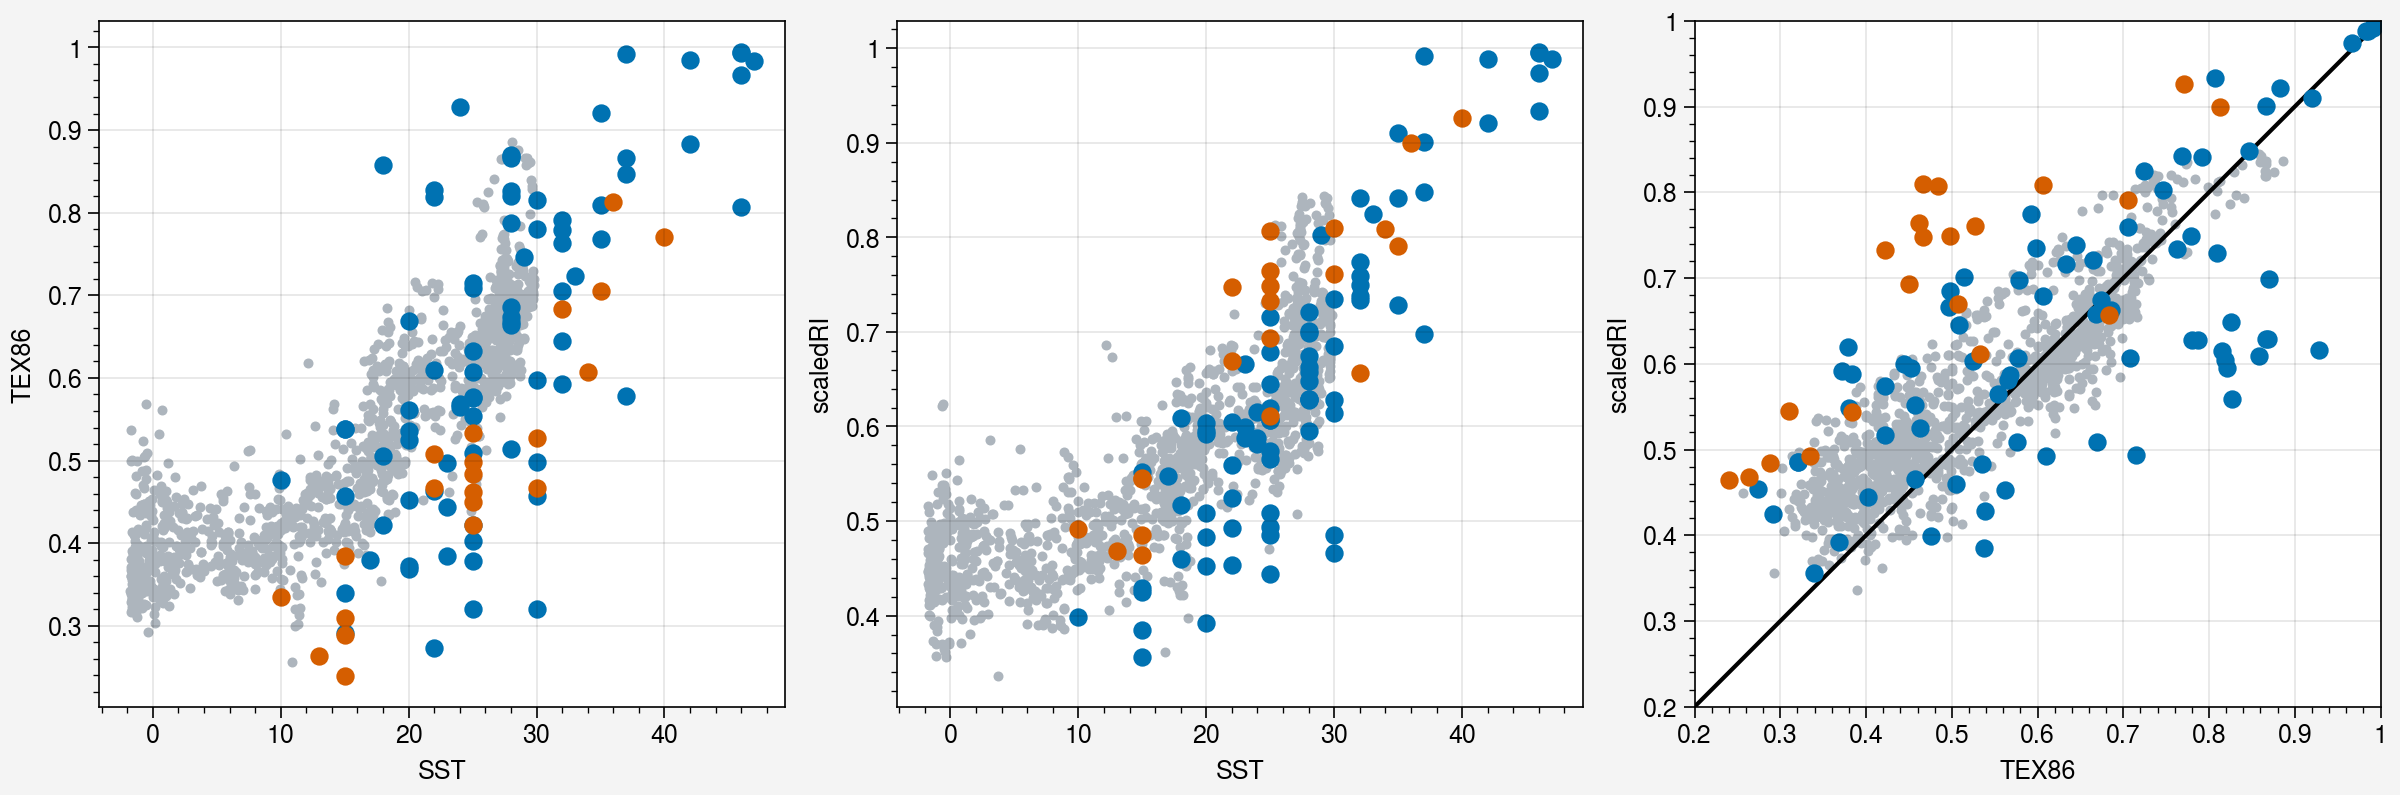

In [62]:
fig, axs = plot.subplots(ncols=3,width=12,share=0)

grouped = plot_data.groupby('datatype')

for name, group in grouped:
    plot_x = group['SST']
    plot_y = group['TEX86']
    axs[0].scatter(plot_x,plot_y)
    
    plot_x = group['SST']
    plot_y = group['scaledRI']
    axs[1].scatter(plot_x,plot_y)
    
    plot_x = group['TEX86']
    plot_y = group['scaledRI']
    axs[2].scatter(plot_x,plot_y)
    
axs[2].plot([0.2,1],[0.2,1],c='k',zorder=0)
axs[2].format(xlim=(0.2,1),ylim=(0.2,1))

plot_x = coretop_df['sst']
plot_y = coretop_df['tex_median']
axs[0].scatter(plot_x,plot_y,m='.',c='gray5',zorder=0)

plot_x = coretop_df['sst']
plot_y = coretop_df['scaledRI_median']
axs[1].scatter(plot_x,plot_y,m='.',c='gray5',zorder=0)

plot_x = coretop_df['tex_median']
plot_y = coretop_df['scaledRI_median']
axs[2].scatter(plot_x,plot_y,m='.',c='gray5',zorder=0)

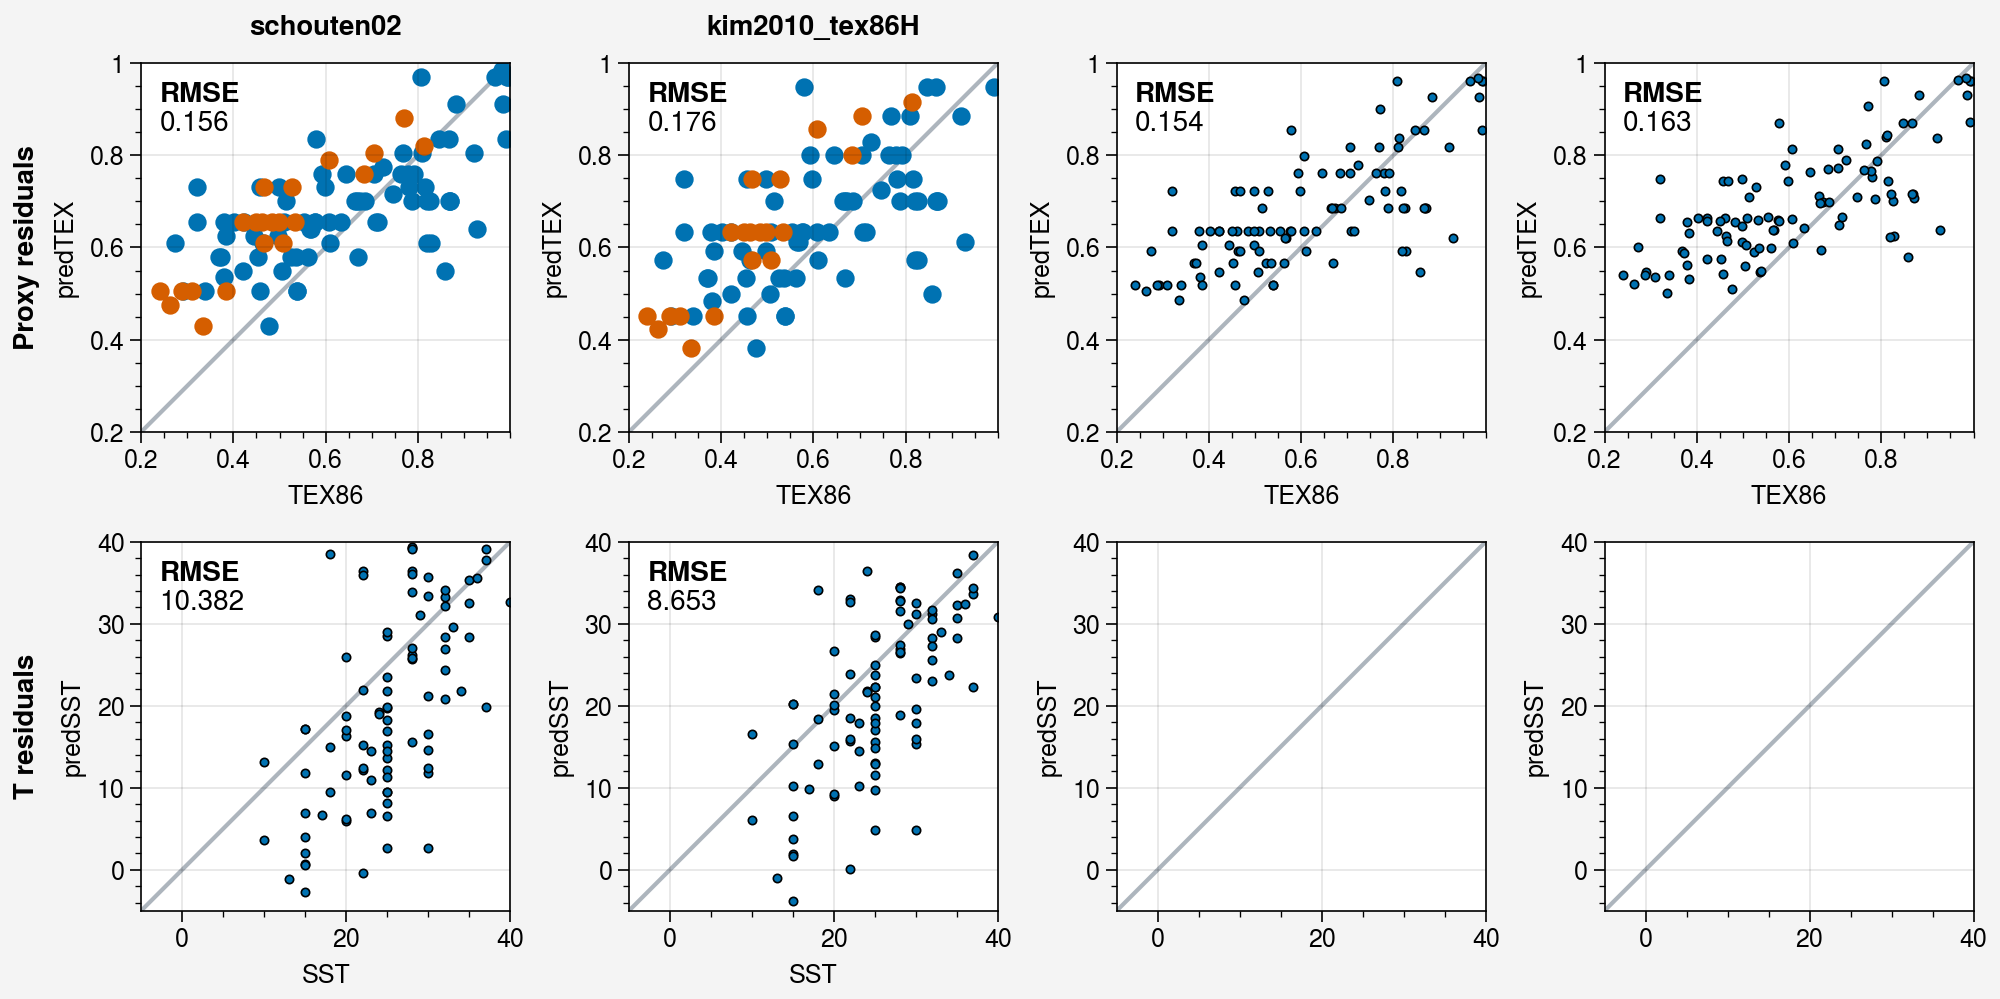

In [46]:
fig, axs = plot.subplots(ncols=4,nrows=2,width=10,share=0)
axs.format(land=True,landcolor='gray3',landzorder=0,
           coast=True,coastzorder=1)


methods = ['schouten2002','kim2010_tex86H']
for i, method in enumerate(methods):
    grouped = plot_data.groupby('datatype')
    for name, group in grouped:
        plot_x = group['TEX86']
        plot_y = group[f'predTEX_{method}']
        axs[0,i].scatter(plot_x,plot_y)
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['TEX86']) & ~np.isnan(plot_data[f'predTEX_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['TEX86'][nonnan_idx],plot_data[f'predTEX_{method}'][nonnan_idx]))

    axs[0,i].text(
        0.05, 0.95, "RMSE", 
        transform=axs[0,i].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[0,i].text(
        0.05, 0.87, f"{rmse_RI_:.3f}", 
        transform=axs[0,i].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    plot_x = plot_data['SST']
    plot_y = plot_data[f'predSST_{method}']
    m2 = axs[1,i].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['SST']) & ~np.isnan(plot_data[f'predSST_{method}'])
    rmse_sst_ = np.sqrt(mean_squared_error(plot_data['SST'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    axs[1,i].text(
        0.05, 0.95, "RMSE", 
        transform=axs[1,i].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[1,i].text(
        0.05, 0.87, f"{rmse_sst_:.3f}", 
        transform=axs[1,i].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )
    
methods = ['Tonly','T-g23r']
for i, method in enumerate(methods):
    plot_x = plot_data['TEX86']
    plot_y = plot_data[f'predRI_{method}']
    m1 = axs[0,i+2].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    
    ### RMSE calculation
    nonnan_idx = ~np.isnan(plot_data['TEX86']) & ~np.isnan(plot_data[f'predRI_{method}'])
    rmse_RI_ = np.sqrt(mean_squared_error(plot_data['TEX86'][nonnan_idx],plot_data[f'predRI_{method}'][nonnan_idx]))

    axs[0,i+2].text(
        0.05, 0.95, "RMSE", 
        transform=axs[0,i+2].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10, fontweight="bold",
    )
    axs[0,i+2].text(
        0.05, 0.87, f"{rmse_RI_:.3f}", 
        transform=axs[0,i+2].transAxes,   # relative to axes [0–1]
        ha="left", va="top", 
        fontsize=10
    )

    # plot_x = plot_data['Temperature']
    # plot_y = plot_data[f'predSST_{method}']
    # m2 = axs[i,1].scatter(plot_x,plot_y,m='.',zorder=2,mec='k')
    
    # ### RMSE calculation
    # nonnan_idx = ~np.isnan(plot_data['Temperature']) & ~np.isnan(plot_data[f'predSST_{method}'])
    # rmse_sst_ = np.sqrt(mean_squared_error(plot_data['Temperature'][nonnan_idx],plot_data[f'predSST_{method}'][nonnan_idx]))
    # axs[i,1].text(
    #     0.05, 0.95, "RMSE", 
    #     transform=axs[i,1].transAxes,   # relative to axes [0–1]
    #     ha="left", va="top", 
    #     fontsize=8, fontweight="bold",
    # )
    # axs[i,1].text(
    #     0.05, 0.87, f"{rmse_sst_:.3f}", 
    #     transform=axs[i,1].transAxes,   # relative to axes [0–1]
    #     ha="left", va="top", 
    #     fontsize=8
    # )


axs.format(
    rowlabels=['Proxy residuals','T residuals'],
    collabels=['schouten02','kim2010_tex86H','','']
)

axs[1:,:].format(ylabel='')

axs[0,:].plot([0.2,1],[0.2,1],c='gray5',zorder=0)
axs[0,:].format(xlim=(0.2,1),xticks=np.arange(0.2,0.81,0.2),
                ylim=(0.2,1),ylabel='predTEX')

axs[1,:].plot([-5,40],[-5,40],c='gray5',zorder=0)
axs[1,:].format(xlim=(-5,40),ylim=(-5,40),ylabel='predSST')